<a href="https://colab.research.google.com/github/tophuonganh129/anh-chan-trang/blob/main/Nh%C3%B3m_12_Churn_Prediction_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔮 Churn Prediction – Nhóm 12
### Mô hình: SMOTE + ENN → Random Forest & Decision Tree → Voting Ensemble
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

## Bước 1 – Đọc và khám phá dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/BTL-Nhóm 12-Trí tuệ nhân tạo/data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

print(f"Kích thước dữ liệu: {df.shape}")
df.head()

Kích thước dữ liệu: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()
print("\nSố lượng dữ liệu bị thiếu ở mỗi cột:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Bước 2 – Tiền xử lý dữ liệu

In [ ]:
# Xóa cột customerID
df = df.drop('customerID', axis=1)

# Ép TotalCharges về kiểu số, điền 0 vào NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Mã hoá biến mục tiêu và One-Hot Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

print("Đã dọn xong! Số lượng ô trống hiện tại:")
print(df.isnull().sum().sum())

Đã dọn xong! Số lượng ô trống hiện tại:
0


## Bước 3 – Chia dữ liệu & Xử lý mất cân bằng bằng **SMOTE + ENN**

| Kỹ thuật | Vai trò |
|---|---|
| **SMOTE** | *Over-sampling* – tạo thêm mẫu thiểu số (Churn=1) tổng hợp |
| **ENN** | *Under-sampling* – loại bỏ các mẫu nhiễu/biên giới khó phân loại |
| **SMOTE+ENN** | Kết hợp cả hai → dữ liệu cân bằng HƠN và SẠCH HƠN |

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN

X = df.drop('Churn', axis=1)
y = df['Churn']

print("Tỷ lệ khách hàng trước khi cân bằng:")
print(y.value_counts())
print("-" * 40)

# Chia train/test trước (tuyệt đối không để ENN/SMOTE nhìn vào tập test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Áp dụng SMOTE + ENN trên tập train
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

print("Tỷ lệ sau SMOTE+ENN (tập Train):")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nSố mẫu train sau xử lý: {len(y_train_resampled)}")

Tỷ lệ khách hàng trước khi cân bằng:
Churn
0    5174
1    1869
Name: count, dtype: int64
----------------------------------------
Tỷ lệ sau SMOTE+ENN (tập Train):
Churn
1    2506
0    2150
Name: count, dtype: int64

Số mẫu train sau xử lý: 4656


/tmp/ipykernel_465/1135103088.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette=palette)
/tmp/ipykernel_465/1135103088.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_smote_only, ax=axes[1], palette=palette)
/tmp/ipykernel_465/1135103088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, ax=axes[2], palette=palette)


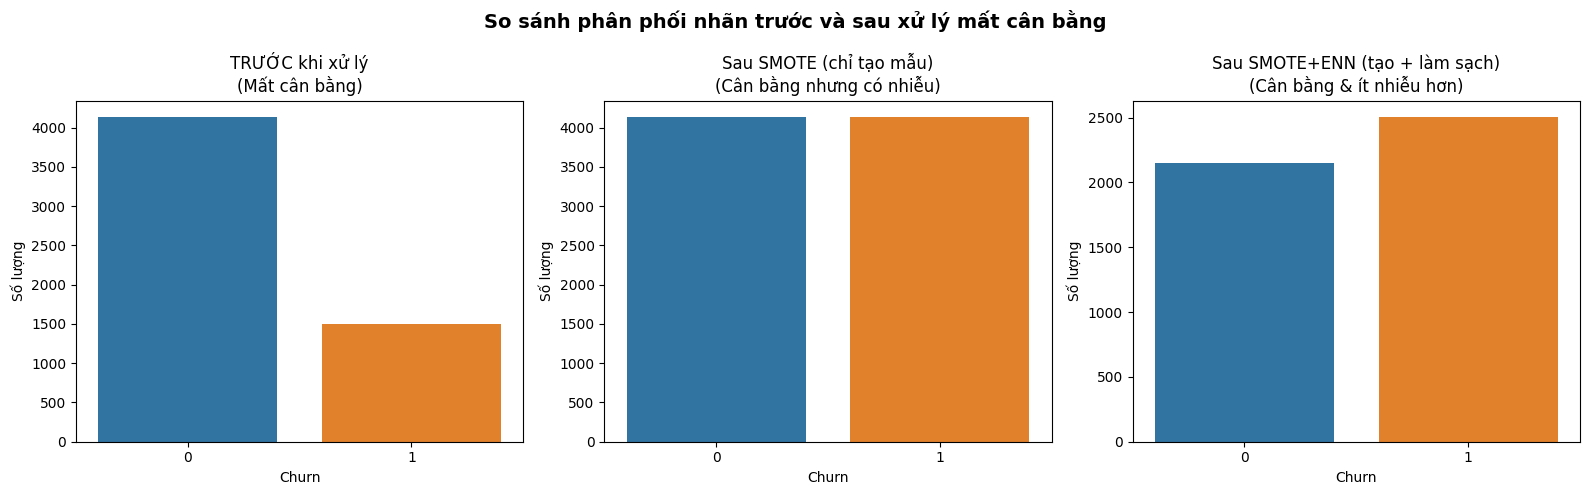

In [ ]:
# Trực quan hoá kết quả SMOTE+ENN
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = ['Ở lại (0)', 'Rời bỏ (1)']
palette = ['#1f77b4', '#ff7f0e']

# Trước xử lý
sns.countplot(x=y_train, ax=axes[0], palette=palette)
axes[0].set_title("TRƯỚC khi xử lý\n(Mất cân bằng)", fontsize=12)
axes[0].set_ylabel("Số lượng")
axes[0].set_xlabel("Churn")

# Giữa chừng: chỉ dùng SMOTE để so sánh
from imblearn.over_sampling import SMOTE
X_smote_only, y_smote_only = SMOTE(random_state=42).fit_resample(X_train, y_train)
sns.countplot(x=y_smote_only, ax=axes[1], palette=palette)
axes[1].set_title("Sau SMOTE (chỉ tạo mẫu)\n(Cân bằng nhưng có nhiễu)", fontsize=12)
axes[1].set_ylabel("Số lượng")
axes[1].set_xlabel("Churn")

# Sau SMOTE+ENN
sns.countplot(x=y_train_resampled, ax=axes[2], palette=palette)
axes[2].set_title("Sau SMOTE+ENN (tạo + làm sạch)\n(Cân bằng & ít nhiễu hơn)", fontsize=12)
axes[2].set_ylabel("Số lượng")
axes[2].set_xlabel("Churn")

plt.suptitle("So sánh phân phối nhãn trước và sau xử lý mất cân bằng", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bước 4 – Huấn luyện mô hình

### 4A – Decision Tree (cây quyết định đơn lẻ)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ── DECISION TREE ──────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=10,           # Giới hạn độ sâu để tránh overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train_resampled, y_train_resampled)
y_pred_dt = dt_model.predict(X_test)

print("=" * 55)
print("  DECISION TREE – Kết quả trên tập Test")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=['Ở lại', 'Rời bỏ']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1]):.4f}")

  DECISION TREE – Kết quả trên tập Test
              precision    recall  f1-score   support

       Ở lại       0.88      0.76      0.82      1035
      Rời bỏ       0.52      0.71      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.75      0.76      1409

ROC-AUC Score: 0.7802


### 4B – Random Forest (rừng ngẫu nhiên)

In [ ]:
# ── RANDOM FOREST ──────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)

print("=" * 55)
print("  RANDOM FOREST – Kết quả trên tập Test")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Ở lại', 'Rời bỏ']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}")

  RANDOM FOREST – Kết quả trên tập Test
              precision    recall  f1-score   support

       Ở lại       0.90      0.74      0.81      1035
      Rời bỏ       0.51      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8317


### 4C – Voting Ensemble (kết hợp Decision Tree + Random Forest)

> **Nguyên lý:** Mỗi mô hình "bỏ phiếu" dự đoán xác suất, kết quả cuối là trung bình có trọng số → quyết định chính xác hơn bất kỳ mô hình đơn lẻ nào.

In [ ]:
from sklearn.ensemble import VotingClassifier

# Tạo mô hình bỏ phiếu mềm (soft voting = bỏ phiếu theo xác suất)
# Trọng số: RF quan trọng hơn (weight=2) vì có độ chính xác cao hơn DT
voting_model = VotingClassifier(
    estimators=[
        ('decision_tree', dt_model),
        ('random_forest', rf_model)
    ],
    voting='soft',          # Dùng xác suất thay vì nhãn trực tiếp
    weights=[1, 2]          # RF có trọng số gấp đôi DT
)

voting_model.fit(X_train_resampled, y_train_resampled)
y_pred_voting = voting_model.predict(X_test)

print("=" * 55)
print("  VOTING ENSEMBLE (DT + RF) – Kết quả trên tập Test")
print("=" * 55)
print(classification_report(y_test, y_pred_voting, target_names=['Ở lại', 'Rời bỏ']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, voting_model.predict_proba(X_test)[:,1]):.4f}")

  VOTING ENSEMBLE (DT + RF) – Kết quả trên tập Test
              precision    recall  f1-score   support

       Ở lại       0.90      0.75      0.82      1035
      Rời bỏ       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

ROC-AUC Score: 0.8314


## Bước 5 – So sánh cả ba mô hình

                Accuracy  Precision (Churn)  Recall (Churn)  F1-Score (Churn)
Mô hình                                                                      
Decision Tree     0.7488             0.5195          0.7112            0.6005
Random Forest     0.7459             0.5144          0.7647            0.6151
Voting (DT+RF)    0.7537             0.5246          0.7701            0.6241


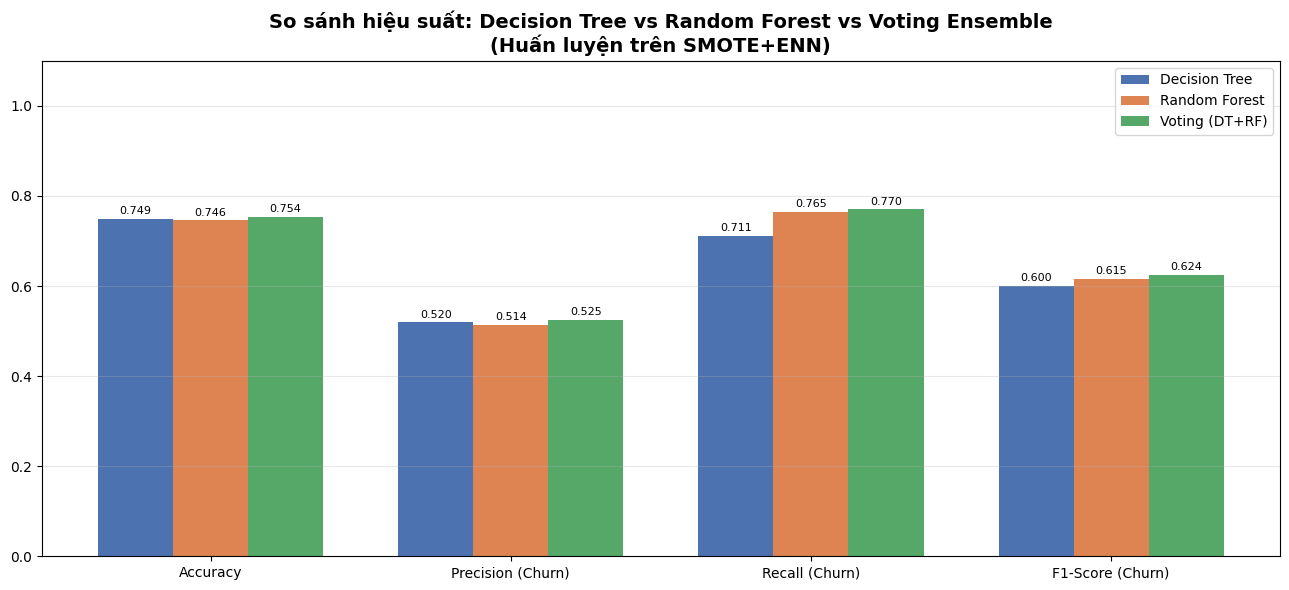

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Voting (DT+RF)': y_pred_voting
}

results = []
for name, y_pred in models.items():
    results.append({
        'Mô hình': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Churn)': precision_score(y_test, y_pred),
        'Recall (Churn)': recall_score(y_test, y_pred),
        'F1-Score (Churn)': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Mô hình')
print(results_df.to_string(float_format='{:.4f}'.format))

# Biểu đồ so sánh
metrics = ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#4c72b0', '#dd8452', '#55a868']
for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics], width, label=model_name, color=colors[i])
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_title('So sánh hiệu suất: Decision Tree vs Random Forest vs Voting Ensemble\n(Huấn luyện trên SMOTE+ENN)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 6 – Confusion Matrix ba mô hình

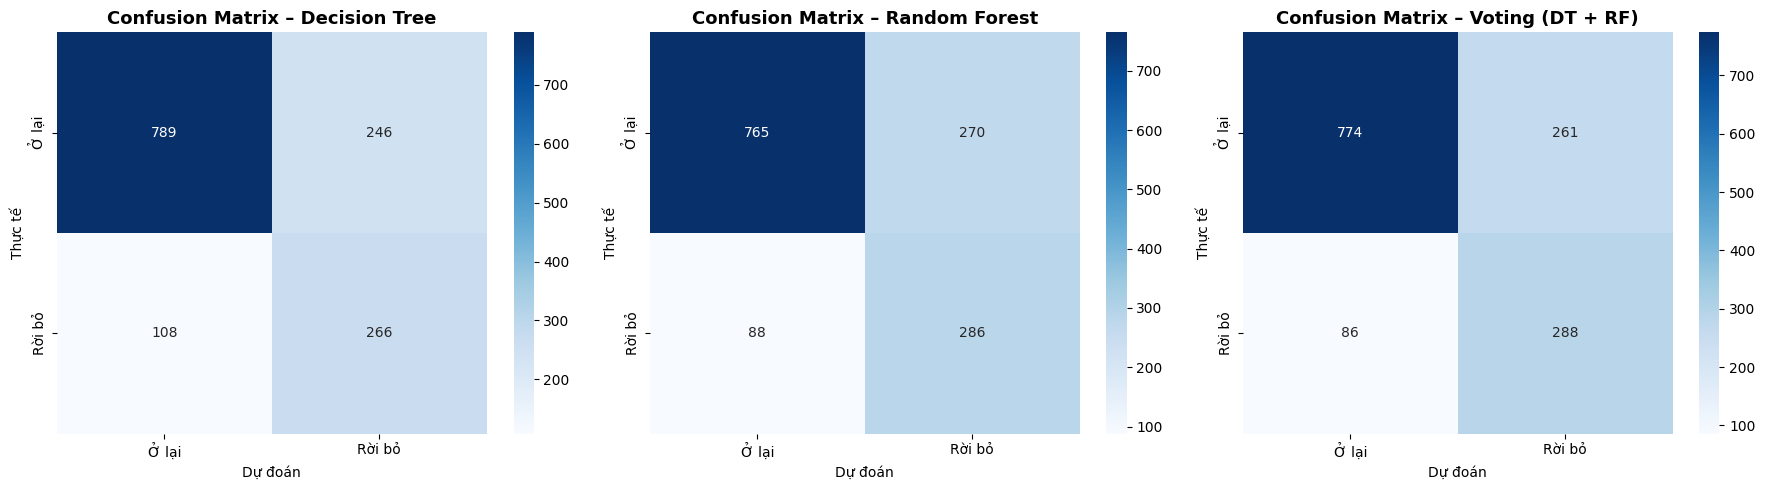

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Decision Tree', 'Random Forest', 'Voting (DT + RF)']
preds  = [y_pred_dt, y_pred_rf, y_pred_voting]

for ax, title, pred in zip(axes, titles, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ở lại', 'Rời bỏ'],
                yticklabels=['Ở lại', 'Rời bỏ'])
    ax.set_title(f'Confusion Matrix – {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

## Bước 7 – ROC Curve ba mô hình

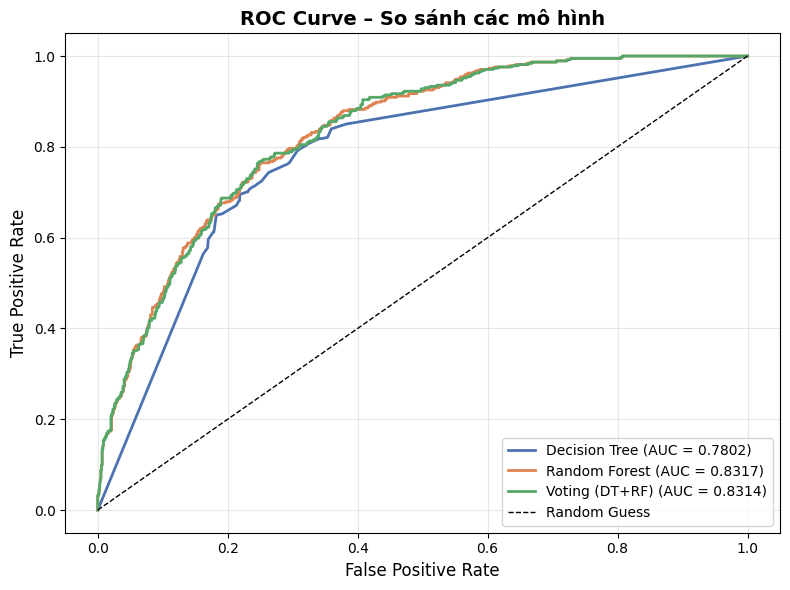

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for model, name, color in [
    (dt_model,     'Decision Tree',    '#4c72b0'),
    (rf_model,     'Random Forest',    '#dd8452'),
    (voting_model, 'Voting (DT+RF)',   '#55a868'),
]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve – So sánh các mô hình', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 8 – Feature Importance (từ Random Forest)

/tmp/ipykernel_465/424363641.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


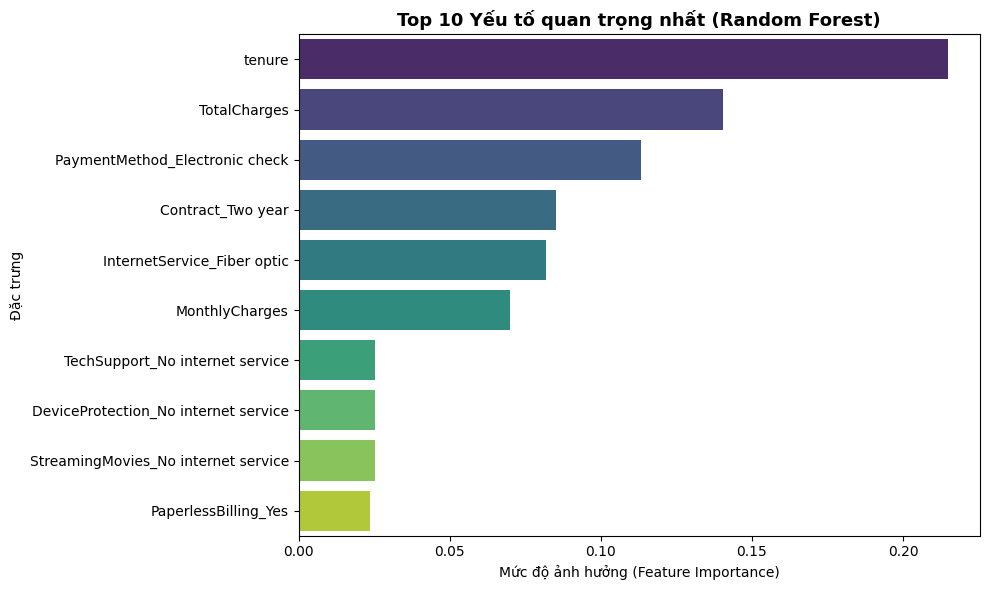

In [ ]:
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Top 10 Yếu tố quan trọng nhất (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Mức độ ảnh hưởng (Feature Importance)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

## Bước 9 – Tìm kiếm siêu tham số cho Voting Ensemble

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("Đang tìm kiếm siêu tham số tốt nhất cho từng mô hình...")

# Tìm tham số tốt nhất cho Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1
)
rf_search.fit(X_train_resampled, y_train_resampled)
print("\n✅ Random Forest – Bộ tham số tốt nhất:", rf_search.best_params_)

# Tìm tham số tốt nhất cho Decision Tree
dt_param_grid = {
    'max_depth': [5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid, n_iter=10, cv=3, verbose=1, random_state=42
)
dt_search.fit(X_train_resampled, y_train_resampled)
print("\n✅ Decision Tree – Bộ tham số tốt nhất:", dt_search.best_params_)

Đang tìm kiếm siêu tham số tốt nhất cho từng mô hình...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Random Forest – Bộ tham số tốt nhất: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Decision Tree – Bộ tham số tốt nhất: {'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 15, 'criterion': 'gini'}


In [ ]:
# Lắp ráp Voting Ensemble cuối cùng với tham số tốt nhất
best_rf  = rf_search.best_estimator_
best_dt  = dt_search.best_estimator_

best_voting = VotingClassifier(
    estimators=[('dt', best_dt), ('rf', best_rf)],
    voting='soft',
    weights=[1, 2]
)
best_voting.fit(X_train_resampled, y_train_resampled)
y_pred_best = best_voting.predict(X_test)

print("=" * 55)
print("  VOTING ENSEMBLE (Tối ưu) – Kết quả cuối cùng")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=['Ở lại', 'Rời bỏ']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, best_voting.predict_proba(X_test)[:,1]):.4f}")

  VOTING ENSEMBLE (Tối ưu) – Kết quả cuối cùng
              precision    recall  f1-score   support

       Ở lại       0.89      0.75      0.82      1035
      Rời bỏ       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8284


## Bước 10 – Lưu mô hình tốt nhất

In [ ]:
import joblib

save_path = '/content/drive/MyDrive/BTL-Nhóm 12-Trí tuệ nhân tạo/src/best_voting_churn_model.pkl'
joblib.dump(best_voting, save_path)
print(f"✅ Đã lưu mô hình Voting Ensemble tại: {save_path}")

# Lưu backup tại thư mục hiện tại
joblib.dump(best_voting, 'best_voting_churn_model.pkl')
print("✅ Đã lưu bản sao tại thư mục hiện tại: best_voting_churn_model.pkl")

✅ Đã lưu mô hình Voting Ensemble tại: /content/drive/MyDrive/BTL-Nhóm 12-Trí tuệ nhân tạo/src/best_voting_churn_model.pkl
✅ Đã lưu bản sao tại thư mục hiện tại: best_voting_churn_model.pkl


## Bước 11 – Demo Web với Flask

In [ ]:
!pip install flask pyngrok
!npm install -g localtunnel

import os
os.makedirs('templates', exist_ok=True)
print(" Đã cài đặt xong!")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 3s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦ Đã cài đặt xong!


In [ ]:
import os
os.makedirs('templates', exist_ok=True)

html_code = """<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Demo Churn Prediction - Nhóm 12</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        body { background-color: #121212; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #ffffff; }
        .card-custom { border-radius: 15px; border: 1px solid #333; background-color: #1e1e1e; box-shadow: 0 10px 30px rgba(0,0,0,0.8); margin-top: 50px; }
        .form-control, .form-select { background-color: #2c2c2c; color: #fff; border: 1px solid #444; }
        .form-control:focus, .form-select:focus { background-color: #3b3b3b; color: #fff; border-color: #198754; box-shadow: 0 0 0 0.25rem rgba(25, 135, 84, 0.25); }
        .form-label { font-weight: 500; color: #d1d1d1; }
        .btn-predict { transition: all 0.3s ease; background-color: #198754; color: white; border-radius: 8px; border: none; }
        .btn-predict:hover { transform: translateY(-2px); box-shadow: 0 8px 15px rgba(25, 135, 84, 0.4); background-color: #157347; }
        .result-box { animation: fadeIn 0.5s ease-in-out; border-radius: 10px; }
        @keyframes fadeIn { from { opacity: 0; transform: scale(0.95); } to { opacity: 1; transform: scale(1); } }
        .alert-danger { background-color: #dc3545 !important; color: #ffffff !important; border: none; }
        .alert-success { background-color: #198754 !important; color: #ffffff !important; border: none; }
        .badge-model { background-color: #0d6efd; font-size: 0.75rem; }
    </style>
</head>
<body>
    <div class="container mb-5">
        <div class="row justify-content-center">
            <div class="col-md-8">
                <div class="card card-custom p-4">
                    <h2 class="text-center mb-1 text-success fw-bold">Dự đoán khả năng rời bỏ dịch vụ</h2>
                    <p class="text-center mb-1" style="color: #adb5bd;">Nhóm 12 – Môn Trí tuệ nhân tạo</p>
                    <form action="/predict" method="POST">
                        <div class="row mb-3">
                            <div class="col-md-6">
                                <label class="form-label">Thâm niên sử dụng (Tháng):</label>
                                <input type="number" class="form-control" name="tenure" required placeholder="VD: 12">
                            </div>
                            <div class="col-md-6">
                                <label class="form-label">Cước phí hàng tháng ($):</label>
                                <input type="number" step="0.01" class="form-control" name="MonthlyCharges" required placeholder="VD: 50.5">
                            </div>
                        </div>
                        <div class="row mb-3">
                            <div class="col-md-4">
                                <label class="form-label">Tổng cước phí ($):</label>
                                <input type="number" step="0.01" class="form-control" name="TotalCharges" required placeholder="VD: 600">
                            </div>
                            <div class="col-md-4">
                                <label class="form-label">Loại hợp đồng:</label>
                                <select class="form-select" name="Contract">
                                    <option value="Month-to-month">Từng tháng</option>
                                    <option value="One year">1 Năm</option>
                                    <option value="Two year">2 Năm</option>
                                </select>
                            </div>
                            <div class="col-md-4">
                                <label class="form-label">Loại Internet:</label>
                                <select class="form-select" name="InternetService">
                                    <option value="DSL">Cáp đồng (DSL)</option>
                                    <option value="Fiber optic">Cáp quang</option>
                                    <option value="No">Không dùng</option>
                                </select>
                            </div>
                        </div>
                        <div class="d-grid mt-4">
                            <button type="submit" class="btn btn-predict btn-lg fw-bold">DỰ ĐOÁN NGAY</button>
                        </div>
                    </form>

                    {% if prediction_text %}
                    <div class="alert {{ alert_class }} mt-4 text-center result-box fs-5 fw-bold shadow-sm">
                        {{ prediction_text }}
                    </div>

                    {% if survival_plot %}
                    <div class="card p-3 mt-3" style="background-color: #2c2c2c; border: 1px solid #444; border-radius: 10px;">
                        <h5 class="text-center text-warning mb-2">⏱ Phân Tích Sống Còn (Survival Analysis)</h5>
                        <div class="text-center">
                            <img src="data:image/png;base64,{{ survival_plot }}" class="img-fluid rounded" alt="Biểu đồ Survival">
                        </div>
                    </div>
                    {% endif %}
                    {% endif %}
                </div>
            </div>
        </div>
    </div>
</body>
</html>"""

with open('templates/index.html', 'w', encoding='utf-8') as f:
    f.write(html_code)

print("Giao diện web!")

Giao diện web!


In [ ]:
%%writefile app.py
from flask import Flask, request, render_template
import joblib
import pandas as pd
import io
import base64
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

app = Flask(__name__)

# =====================================================================
# 1. TẢI MÔ HÌNH VÀ CHUẨN BỊ DỮ LIỆU KHI KHỞI ĐỘNG SERVER
# =====================================================================
model = joblib.load('best_voting_churn_model.pkl')
model_columns = model.estimators_[1].feature_names_in_

# Huấn luyện Cox với đầy đủ đặc trưng để đường survival phân biệt được khách hàng
df_survival = pd.read_csv('/content/drive/MyDrive/BTL-Nhóm 12-Trí tuệ nhân tạo/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_survival['TotalCharges'] = pd.to_numeric(df_survival['TotalCharges'], errors='coerce')
df_survival = df_survival.dropna(subset=['TotalCharges'])
df_survival['Churn_binary'] = df_survival['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# ✅ SỬA: Dùng nhiều đặc trưng hơn (thay vì chỉ 3 biến cũ)
selected_features = [
    'tenure', 'Churn_binary',
    'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'Partner', 'Dependents'
]
df_cox = df_survival[selected_features].copy()
df_cox = pd.get_dummies(df_cox, columns=[
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'Partner', 'Dependents'
], drop_first=True)

# Lưu danh sách cột đặc trưng (bỏ duration và event)
cox_feature_cols = [c for c in df_cox.columns if c not in ['tenure', 'Churn_binary']]

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox, duration_col='tenure', event_col='Churn_binary')

# =====================================================================
# 2. XỬ LÝ GIAO DIỆN VÀ DỰ ĐOÁN
# =====================================================================
@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    tenure          = float(request.form['tenure'])
    monthly_charges = float(request.form['MonthlyCharges'])
    total_charges   = float(request.form['TotalCharges'])
    contract        = request.form['Contract']
    internet        = request.form['InternetService']
    payment         = request.form.get('PaymentMethod', 'Electronic check')
    senior          = int(request.form.get('SeniorCitizen', 0))
    online_sec      = request.form.get('OnlineSecurity', 'No')
    tech_support    = request.form.get('TechSupport', 'No')
    paperless       = request.form.get('PaperlessBilling', 'Yes')
    partner         = request.form.get('Partner', 'No')
    dependents      = request.form.get('Dependents', 'No')

    # --- MÔ HÌNH CLASSIFICATION (Voting Ensemble) ---
    input_data = pd.DataFrame(columns=model_columns)
    input_data.loc[0] = 0
    input_data['tenure']         = tenure
    input_data['MonthlyCharges'] = monthly_charges
    input_data['TotalCharges']   = total_charges
    if contract == 'One year' and 'Contract_One year' in model_columns:
        input_data['Contract_One year'] = 1
    elif contract == 'Two year' and 'Contract_Two year' in model_columns:
        input_data['Contract_Two year'] = 1
    if internet == 'Fiber optic' and 'InternetService_Fiber optic' in model_columns:
        input_data['InternetService_Fiber optic'] = 1
    elif internet == 'No' and 'InternetService_No' in model_columns:
        input_data['InternetService_No'] = 1

    prob = model.predict_proba(input_data)[0][1]
    if prob >= 0.5:
        result      = f"🚨 CẢNH BÁO: Khách hàng có NGUY CƠ RỜI BỎ CAO ({prob * 100:.1f}%)"
        color_class = "alert-danger"
    else:
        result      = f"✅ AN TOÀN: Khách hàng có xu hướng tiếp tục gắn bó ({prob * 100:.1f}% nguy cơ rời bỏ)"
        color_class = "alert-success"

    # --- VẼ BIỂU ĐỒ SURVIVAL (ĐÃ SỬA) ---
    # ✅ SỬA: Tạo đầy đủ tất cả cột mà Cox cần, khởi tạo = 0 trước
    row = {col: 0 for col in cox_feature_cols}

    # Điền các giá trị số
    row['MonthlyCharges'] = monthly_charges
    row['TotalCharges']   = total_charges
    row['SeniorCitizen']  = senior

    # One-hot các biến phân loại
    if contract == 'One year'  and 'Contract_One year'  in row: row['Contract_One year']  = 1
    if contract == 'Two year'  and 'Contract_Two year'  in row: row['Contract_Two year']  = 1
    if internet == 'Fiber optic' and 'InternetService_Fiber optic' in row: row['InternetService_Fiber optic'] = 1
    if internet == 'No'          and 'InternetService_No'          in row: row['InternetService_No']          = 1

    pay_col = f'PaymentMethod_{payment}'
    if pay_col in row: row[pay_col] = 1

    if online_sec  == 'Yes' and 'OnlineSecurity_Yes'    in row: row['OnlineSecurity_Yes']    = 1
    if tech_support == 'Yes' and 'TechSupport_Yes'       in row: row['TechSupport_Yes']       = 1
    if paperless   == 'Yes' and 'PaperlessBilling_Yes'  in row: row['PaperlessBilling_Yes']  = 1
    if partner     == 'Yes' and 'Partner_Yes'            in row: row['Partner_Yes']            = 1
    if dependents  == 'Yes' and 'Dependents_Yes'         in row: row['Dependents_Yes']         = 1

    customer_data = pd.DataFrame([row])[cox_feature_cols]  # đảm bảo đúng thứ tự cột
    survival_prob = cph.predict_survival_function(customer_data)

    plt.figure(figsize=(6, 3.5))
    plt.style.use('dark_background')
    plt.plot(survival_prob.index, survival_prob.values, color='#198754', linewidth=2.5)
    plt.title("Dự báo vòng đời duy trì dịch vụ", color='#ffffff', fontsize=11, fontweight='bold', pad=10)
    plt.xlabel("Thời gian (Tháng)", color='#adb5bd', fontsize=9)
    plt.ylabel("Xác suất ở lại (0.0 -> 1.0)", color='#adb5bd', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.tight_layout()

    img = io.BytesIO()
    plt.savefig(img, format='png', facecolor='#1e1e1e', edgecolor='none')
    img.seek(0)
    survival_plot_base64 = base64.b64encode(img.getvalue()).decode('utf-8')
    plt.close()

    return render_template('index.html',
                           prediction_text=result,
                           alert_class=color_class,
                           survival_plot=survival_plot_base64)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)


Overwriting app.py


Cải tiến

In [ ]:
#Bổ sung thư viện
!pip install -q lifelines

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

In [ ]:
df_survival = pd.read_csv('/content/drive/MyDrive/BTL-Nhóm 12-Trí tuệ nhân tạo/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Tiền xử lý dữ liệu cho Phân tích sống còn


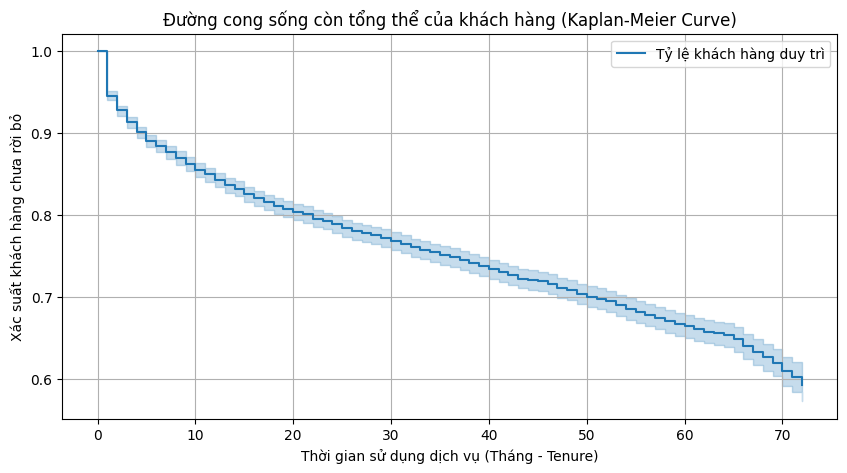

In [ ]:
df_survival['TotalCharges'] = pd.to_numeric(df_survival['TotalCharges'], errors='coerce')
df_survival = df_survival.dropna(subset=['TotalCharges'])
# Chuyển đổi biến Churn sang dạng số nhị phân (1: Khách hủy dịch vụ, 0: Khách ở lại)
df_survival['Churn_binary'] = df_survival['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
print("Tiền xử lý dữ liệu cho Phân tích sống còn")
# ĐỀ XUẤT 1: ƯỚC LƯỢNG KAPLAN-MEIER
kmf = KaplanMeierFitter()
kmf.fit(durations=df_survival['tenure'], event_observed=df_survival['Churn_binary'])
plt.figure(figsize=(10, 5))
kmf.plot_survival_function(label="Tỷ lệ khách hàng duy trì")
plt.title('Đường cong sống còn tổng thể của khách hàng (Kaplan-Meier Curve)')
plt.xlabel('Thời gian sử dụng dịch vụ (Tháng - Tenure)')
plt.ylabel('Xác suất khách hàng chưa rời bỏ')
plt.grid(True)
plt.show()

KẾT QUẢ TÓM TẮT TỪ MÔ HÌNH COX HAZARD


<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn_binary'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -13989.31
         time fit was run = 2026-06-08 22:35:19 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
MonthlyCharges                         0.00      1.00      0.00            0.00            0.00                1.00                1.00
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
SeniorCitizen                          0.04      1.04      0.05           -0.06            0.13                0.94                1.14
Contract_One year                     -0.70      0.50      0.06           -0.81           -0.58                0.45                0.56
Contract_Two year                     -1.11      0.33      0.07           -1.24           -0.98                0.29                0.38
InternetService_Fiber optic            0.53      1.69      0.05            0.43            0.63                1.53                1.87
InternetService_No                    -0.38      0.68      0.08           -0.54           -0.22                0.58                0.80
PaymentMethod_Credit card (automatic) -0.20      0.82      0.06           -0.31           -0.08                0.73                0.92
PaymentMethod_Electronic check         0.39      1.48      0.05            0.30            0.48                1.35                1.62
PaymentMethod_Mailed check             0.24      1.27      0.06            0.12            0.35                1.13                1.42
OnlineSecurity_No internet service    -0.38      0.68      0.08           -0.54           -0.22                0.58                0.80
OnlineSecurity_Yes                    -0.41      0.66      0.05           -0.51           -0.31                0.60                0.73
TechSupport_No internet service       -0.38      0.68      0.08           -0.54           -0.22                0.58                0.80
TechSupport_Yes                       -0.33      0.72      0.05           -0.43           -0.23                0.65                0.79
PaperlessBilling_Yes                   0.18      1.20      0.04            0.09            0.27                1.10                1.31
Partner_Yes                           -0.32      0.72      0.04           -0.41           -0.24                0.67                0.79
Dependents_Yes                        -0.16      0.85      0.05           -0.26           -0.06                0.77                0.94

                                       cmp to      z      p  -log2(p)
covariate                                                            
MonthlyCharges                           0.00   2.93 <0.005      8.22
TotalCharges                             0.00 -30.66 <0.005    683.47
SeniorCitizen                            0.00   0.77   0.44      1.18
Contract_One year                        0.00 -12.02 <0.005    108.09
Contract_Two year                        0.00 -16.81 <0.005    208.32
InternetService_Fiber optic              0.00  10.20 <0.005     78.77
InternetService_No                       0.00  -4.74 <0.005     18.80
PaymentMethod_Credit card (automatic)    0.00  -3.41 <0.005     10.57
PaymentMethod_Electronic check           0.00   8.34 <0.005     53.54
PaymentMethod_Mailed check               0.00   4.10 <0.005     14.55
OnlineSecurity_No internet service       0.00  -4.74 <0.005     18.80
OnlineSecurity_Yes                       0.00  -8.16 <0.005     51.35

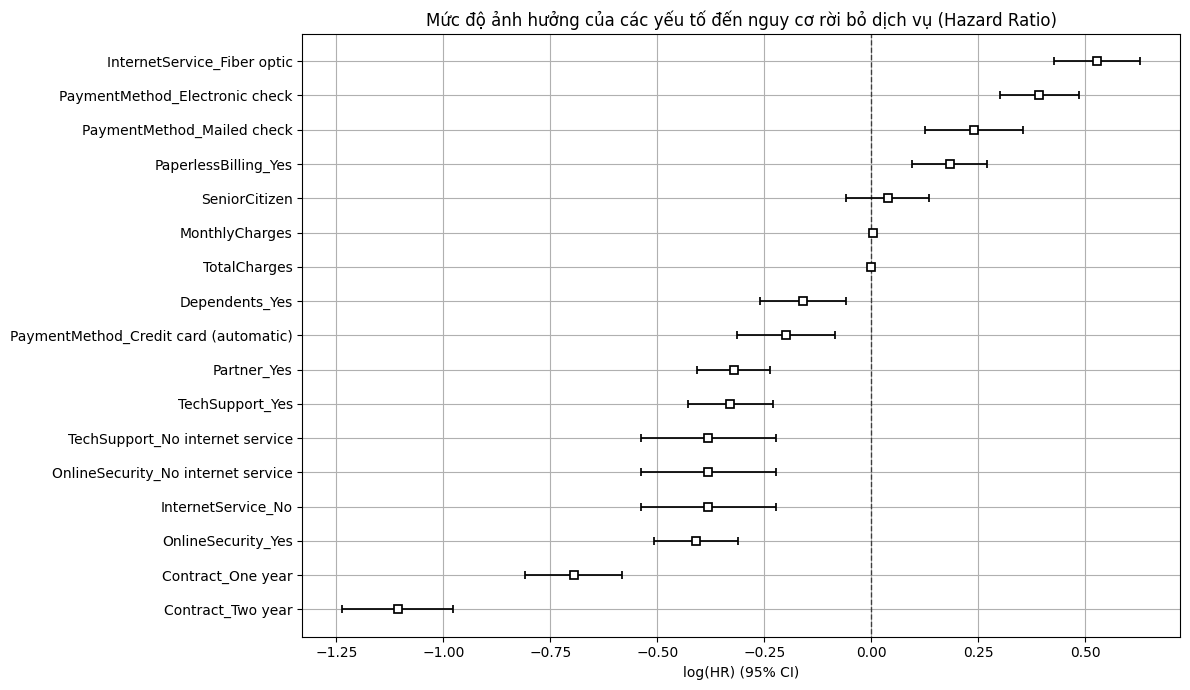


--- Kiểm tra: đường survival của 3 khách hàng điển hình ---


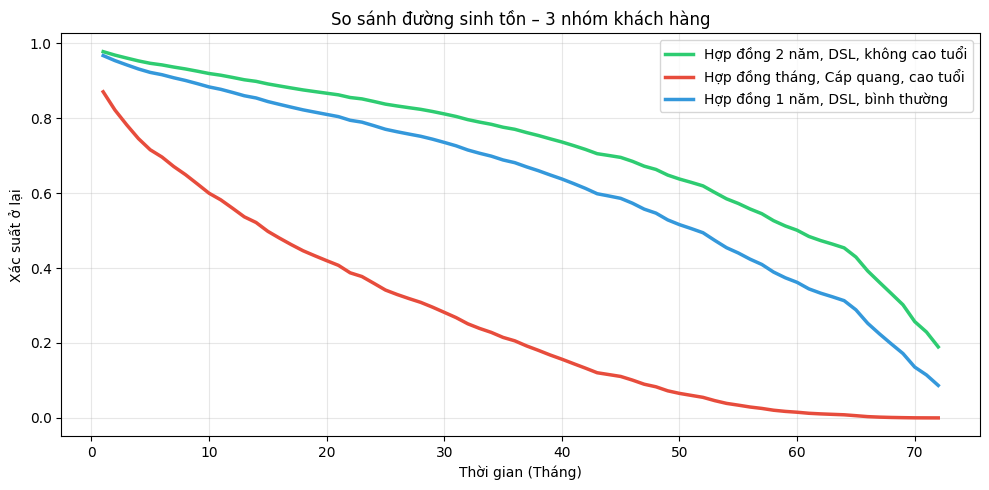

In [ ]:
#Đề xuất 2: MÔ HÌNH NGUY CƠ TỶ LỆ COX (Cox Proportional Hazards Model)
selected_features = [
    'tenure', 'Churn_binary',
    'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'Partner', 'Dependents'
]
df_cox = df_survival[selected_features].copy()
df_cox = pd.get_dummies(df_cox, columns=[
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'Partner', 'Dependents'
], drop_first=True)

# Lưu lại tên cột để dùng khi dự đoán
cox_feature_cols = [c for c in df_cox.columns if c not in ['tenure', 'Churn_binary']]

# penalizer=0.1 giúp ổn định khi có nhiều biến
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox, duration_col='tenure', event_col='Churn_binary')

print("KẾT QUẢ TÓM TẮT TỪ MÔ HÌNH COX HAZARD")
cph.print_summary()

plt.figure(figsize=(12, 7))
cph.plot()
plt.title('Mức độ ảnh hưởng của các yếu tố đến nguy cơ rời bỏ dịch vụ (Hazard Ratio)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Demo: vẽ đường survival cho 3 nhóm khách hàng điển hình để kiểm tra
print("\n--- Kiểm tra: đường survival của 3 khách hàng điển hình ---")
profiles = [
    {'label': 'Hợp đồng 2 năm, DSL, không cao tuổi',
     'MonthlyCharges': 45, 'TotalCharges': 540, 'SeniorCitizen': 0,
     'Contract_One year': 0, 'Contract_Two year': 1,
     'InternetService_Fiber optic': 0, 'InternetService_No': 0},
    {'label': 'Hợp đồng tháng, Cáp quang, cao tuổi',
     'MonthlyCharges': 85, 'TotalCharges': 510, 'SeniorCitizen': 1,
     'Contract_One year': 0, 'Contract_Two year': 0,
     'InternetService_Fiber optic': 1, 'InternetService_No': 0},
    {'label': 'Hợp đồng 1 năm, DSL, bình thường',
     'MonthlyCharges': 60, 'TotalCharges': 720, 'SeniorCitizen': 0,
     'Contract_One year': 1, 'Contract_Two year': 0,
     'InternetService_Fiber optic': 0, 'InternetService_No': 0},
]

plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']
for profile, color in zip(profiles, colors):
    row = {col: 0 for col in cox_feature_cols}
    for k, v in profile.items():
        if k in row:
            row[k] = v
    df_input = pd.DataFrame([row])
    sf = cph.predict_survival_function(df_input)
    plt.plot(sf.index, sf.values, color=color, linewidth=2.5, label=profile['label'])

plt.title('So sánh đường sinh tồn – 3 nhóm khách hàng')
plt.xlabel('Thời gian (Tháng)')
plt.ylabel('Xác suất ở lại')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
!pkill -f "python app.py"

from google.colab.output import eval_js
print("=" * 60)
print("🚀 BẤM VÀO LINK NÀY ĐỂ XEM WEB DEMO:")
print(eval_js("google.colab.kernel.proxyPort(5000)"))
print("=" * 60)

!python app.py

🚀 BẤM VÀO LINK NÀY ĐỂ XEM WEB DEMO:
https://5000-m-s-kkb-usw3b2-26vgjltm0s00l-b.us-west3-2.prod.colab.dev
 * Serving Flask app 'app'
 * Debug mode: off
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
Press CTRL+C to quit
127.0.0.1 - - [08/Jun/2026 23:09:08] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [08/Jun/2026 23:09:52] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [08/Jun/2026 23:10:39] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [08/Jun/2026 23:11:03] "POST /predict HTTP/1.1" 200 -
